In [29]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Literal, Annotated, List
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
import operator

In [30]:
load_dotenv()

True

In [31]:
model = ChatGroq(
    model_name= 'llama-3.3-70b-versatile',
    temperature= 0.7
)

In [32]:
class PostState(TypedDict):
    topic: str
    generated_post: str
    evaluator: Literal['approved', 'needs improvement']
    feedback: str
    iteration: int
    max_iteration: int

    generated_post_history: Annotated[List[str], operator.add ]
    feedback_history: Annotated[List[str], operator.add ]

In [33]:
class EvaluationSchema(BaseModel):
    response: Annotated[Literal['approved', 'needs improvement'], Field(..., description="Final Evaluation result ")]
    feedback: Annotated[str, Field(..., description="Give the feedback about the post")]

evaluation_model = model.with_structured_output(EvaluationSchema)

In [41]:
def generate_post(state: PostState):
    prompt = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]
    response = model.invoke(prompt).content

    return {'generated_post': response, 'generated_post_history': [response]}


In [42]:
def evaluator(state: PostState):
    prompt = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['generated_post']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]
    result = evaluation_model.invoke(prompt)

    return {'evaluator': result.response, 'feedback': result.feedback, 'feedback_history': [result.feedback]}
    

In [43]:
def optimize(state: PostState):
    prompt = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['generated_post']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    result = evaluation_model.invoke(prompt)

    iteration = state['iteration'] + 1

    return {'generated_post': result.content, 'iteration': iteration, 'feedback_history': [result.content]}

In [44]:
def check_condition(state: PostState):

    if state['evaluator'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs improvement'

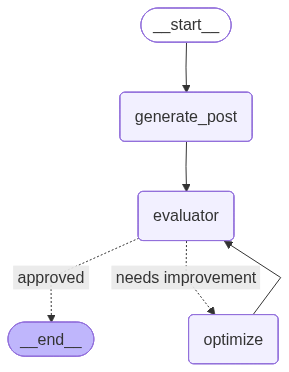

In [45]:
graph = StateGraph(PostState)

graph.add_node('generate_post', generate_post)
graph.add_node('evaluator', evaluator)
graph.add_node('optimize', optimize)

graph.add_edge(START, 'generate_post')
graph.add_edge('generate_post', 'evaluator')
graph.add_conditional_edges('evaluator', check_condition, {'approved': END, 'needs improvement': 'optimize'})
graph.add_edge('optimize', 'evaluator')

workflow = graph.compile()

workflow

In [46]:
initial_state = {
    "topic": "srhberhb",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [47]:
result

{'topic': 'srhberhb',
 'generated_post': '"just spent 10 mins typing \'srhberhb\' and I\'m pretty sure I just invented a new language or a password to a secret society"',
 'evaluator': 'approved',
 'feedback': "This tweet is a gem. It's original, humorous, and punchy, making it a perfect blend of creativity and wit. The idea of spending 10 minutes typing 'srhberhb' and thinking it's a new language or password is relatable and absurd, which adds to the humor. The tweet is well-formed, under 280 characters, and doesn't follow a traditional setup-punchline format. The language is concise, and the tone is playful, making it scroll-stopping and potentially viral. Overall, this tweet has a great balance of humor, originality, and format, making it a strong contender for retweets and shares.",
 'iteration': 1,
 'max_iteration': 5,
 'generated_post_history': ['"just spent 10 mins typing \'srhberhb\' and I\'m pretty sure I just invented a new language or a password to a secret society"'],
 'fee